In [63]:
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
from pandas import DataFrame
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
import math
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score


In [64]:
def kfold(dt, X_train_val, y_train_val):
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    scores_list = []

    for train_i, val_i in kf.split(X_train_val):
        X_train = X_train_val.iloc[train_i]
        X_val = X_train_val.iloc[val_i]
        y_train = y_train_val.iloc[train_i]
        y_val = y_train_val.iloc[val_i]

        dt.fit(X_train, y_train)

        y_pred = dt.predict(X_val)
        scores_list.append(f1_score(y_val, y_pred))

    print(f'Mean F1: {sum(scores_list)/len(scores_list) * 100:.2f}')

In [65]:
# dataset 

np.random.seed(42)

DATASET_PATH = kagglehub.dataset_download(
    "uciml/mushroom-classification"
)

df = pd.read_csv(f"{DATASET_PATH}/mushrooms.csv")

print('Head:', df.head())

print(len(df))

Head:   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1 

In [66]:
# dataset info
print('======Info======')
df.info()

print('======Desctiption======')
df.describe

======Info======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-c

<bound method NDFrame.describe of      class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0        p         x           s         n       t    p               f   
1        e         x           s         y       t    a               f   
2        e         b           s         w       t    l               f   
3        p         x           y         w       t    p               f   
4        e         x           s         g       f    n               f   
...    ...       ...         ...       ...     ...  ...             ...   
8119     e         k           s         n       f    n               a   
8120     e         x           s         n       f    n               a   
8121     e         f           s         n       f    n               a   
8122     p         k           y         n       f    y               f   
8123     e         x           s         n       f    n               a   

     gill-spacing gill-size gill-color  ... stalk-surface-below-r

## A Cleaning the data

In [ ]:
# validation

valid_values = {
    'class': {'e','p'},
    'cap-shape': {'b','c','x','f','k','s'},
    'cap-surface': {'f','g','y','s'},
    'cap-color': {'n','b','c','g','r','p','u','e','w','y'},
    'bruises': {'t','f'},
    'odor': {'a','l','c','y','f','m','n','p','s'},
    'gill-attachment': {'a','d','f','n'},
    'gill-spacing': {'c','w','d'},
    'gill-size': {'b','n'},
    'gill-color': {'k','n','b','h','g','r','o','p','u','e','w','y'},
    'stalk-shape': {'e','t'},
    'stalk-root': {'b','c','u','e','z','r'},
    'stalk-surface-above-ring': {'f','y','k','s'},
    'stalk-surface-below-ring': {'f','y','k','s'},
    'stalk-color-above-ring': {'n','b','c','g','o','p','e','w','y'},
    'stalk-color-below-ring': {'n','b','c','g','o','p','e','w','y'},
    'veil-type': {'p','u'},
    'veil-color': {'n','o','w','y'},
    'ring-number': {'n','o','t'},
    'ring-type': {'c','e','f','l','n','p','s','z'},
    'spore-print-color': {'k','n','b','h','r','o','u','w','y'},
    'population': {'a','c','n','s','v','y'},
    'habitat': {'g','l','m','p','u','w','d'}
}

# all values in the set are aligned with what is expected
print('===Invalid check===')
for column, valid in valid_values.items():
    invalid = set(df[column].unique()) - valid
    if invalid: 
        print(f'{column} has invalid: {invalid}')
    # else:
    #     print(f'{column} is good')

print('===Unique check===')
# check for columns with constant values:
for column in df.columns:
    unique = df[column].nunique()
    if unique <= 1:
        print(f'{column} constant')
    # else:
    #     print(f'{column} not unique')

===Invalid check===
===Unique check===
veil-type constant


In [ ]:
# mode
valid_values['stalk-root'] = {'b', 'c', 'u', 'e', 'z', 'r'}

# replace ? with pd.NA then mode impute
df['stalk-root'] = df['stalk-root'].replace('?', pd.NA)
df['stalk-root'] = df['stalk-root'].fillna(df['stalk-root'].mode()[0])
print(df['stalk-root'].unique())

['e' 'c' 'b' 'r' '?']


In [69]:
print('===Invalid check===')
for column, valid in valid_values.items():
    invalid = set(df[column].unique()) - valid
    if invalid: 
        print(f'{column} has invalid: {invalid}')

===Invalid check===


## B Numerical label Encoding

In [70]:
df_encoded = df.copy()
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

## C EDA and Outlier detection

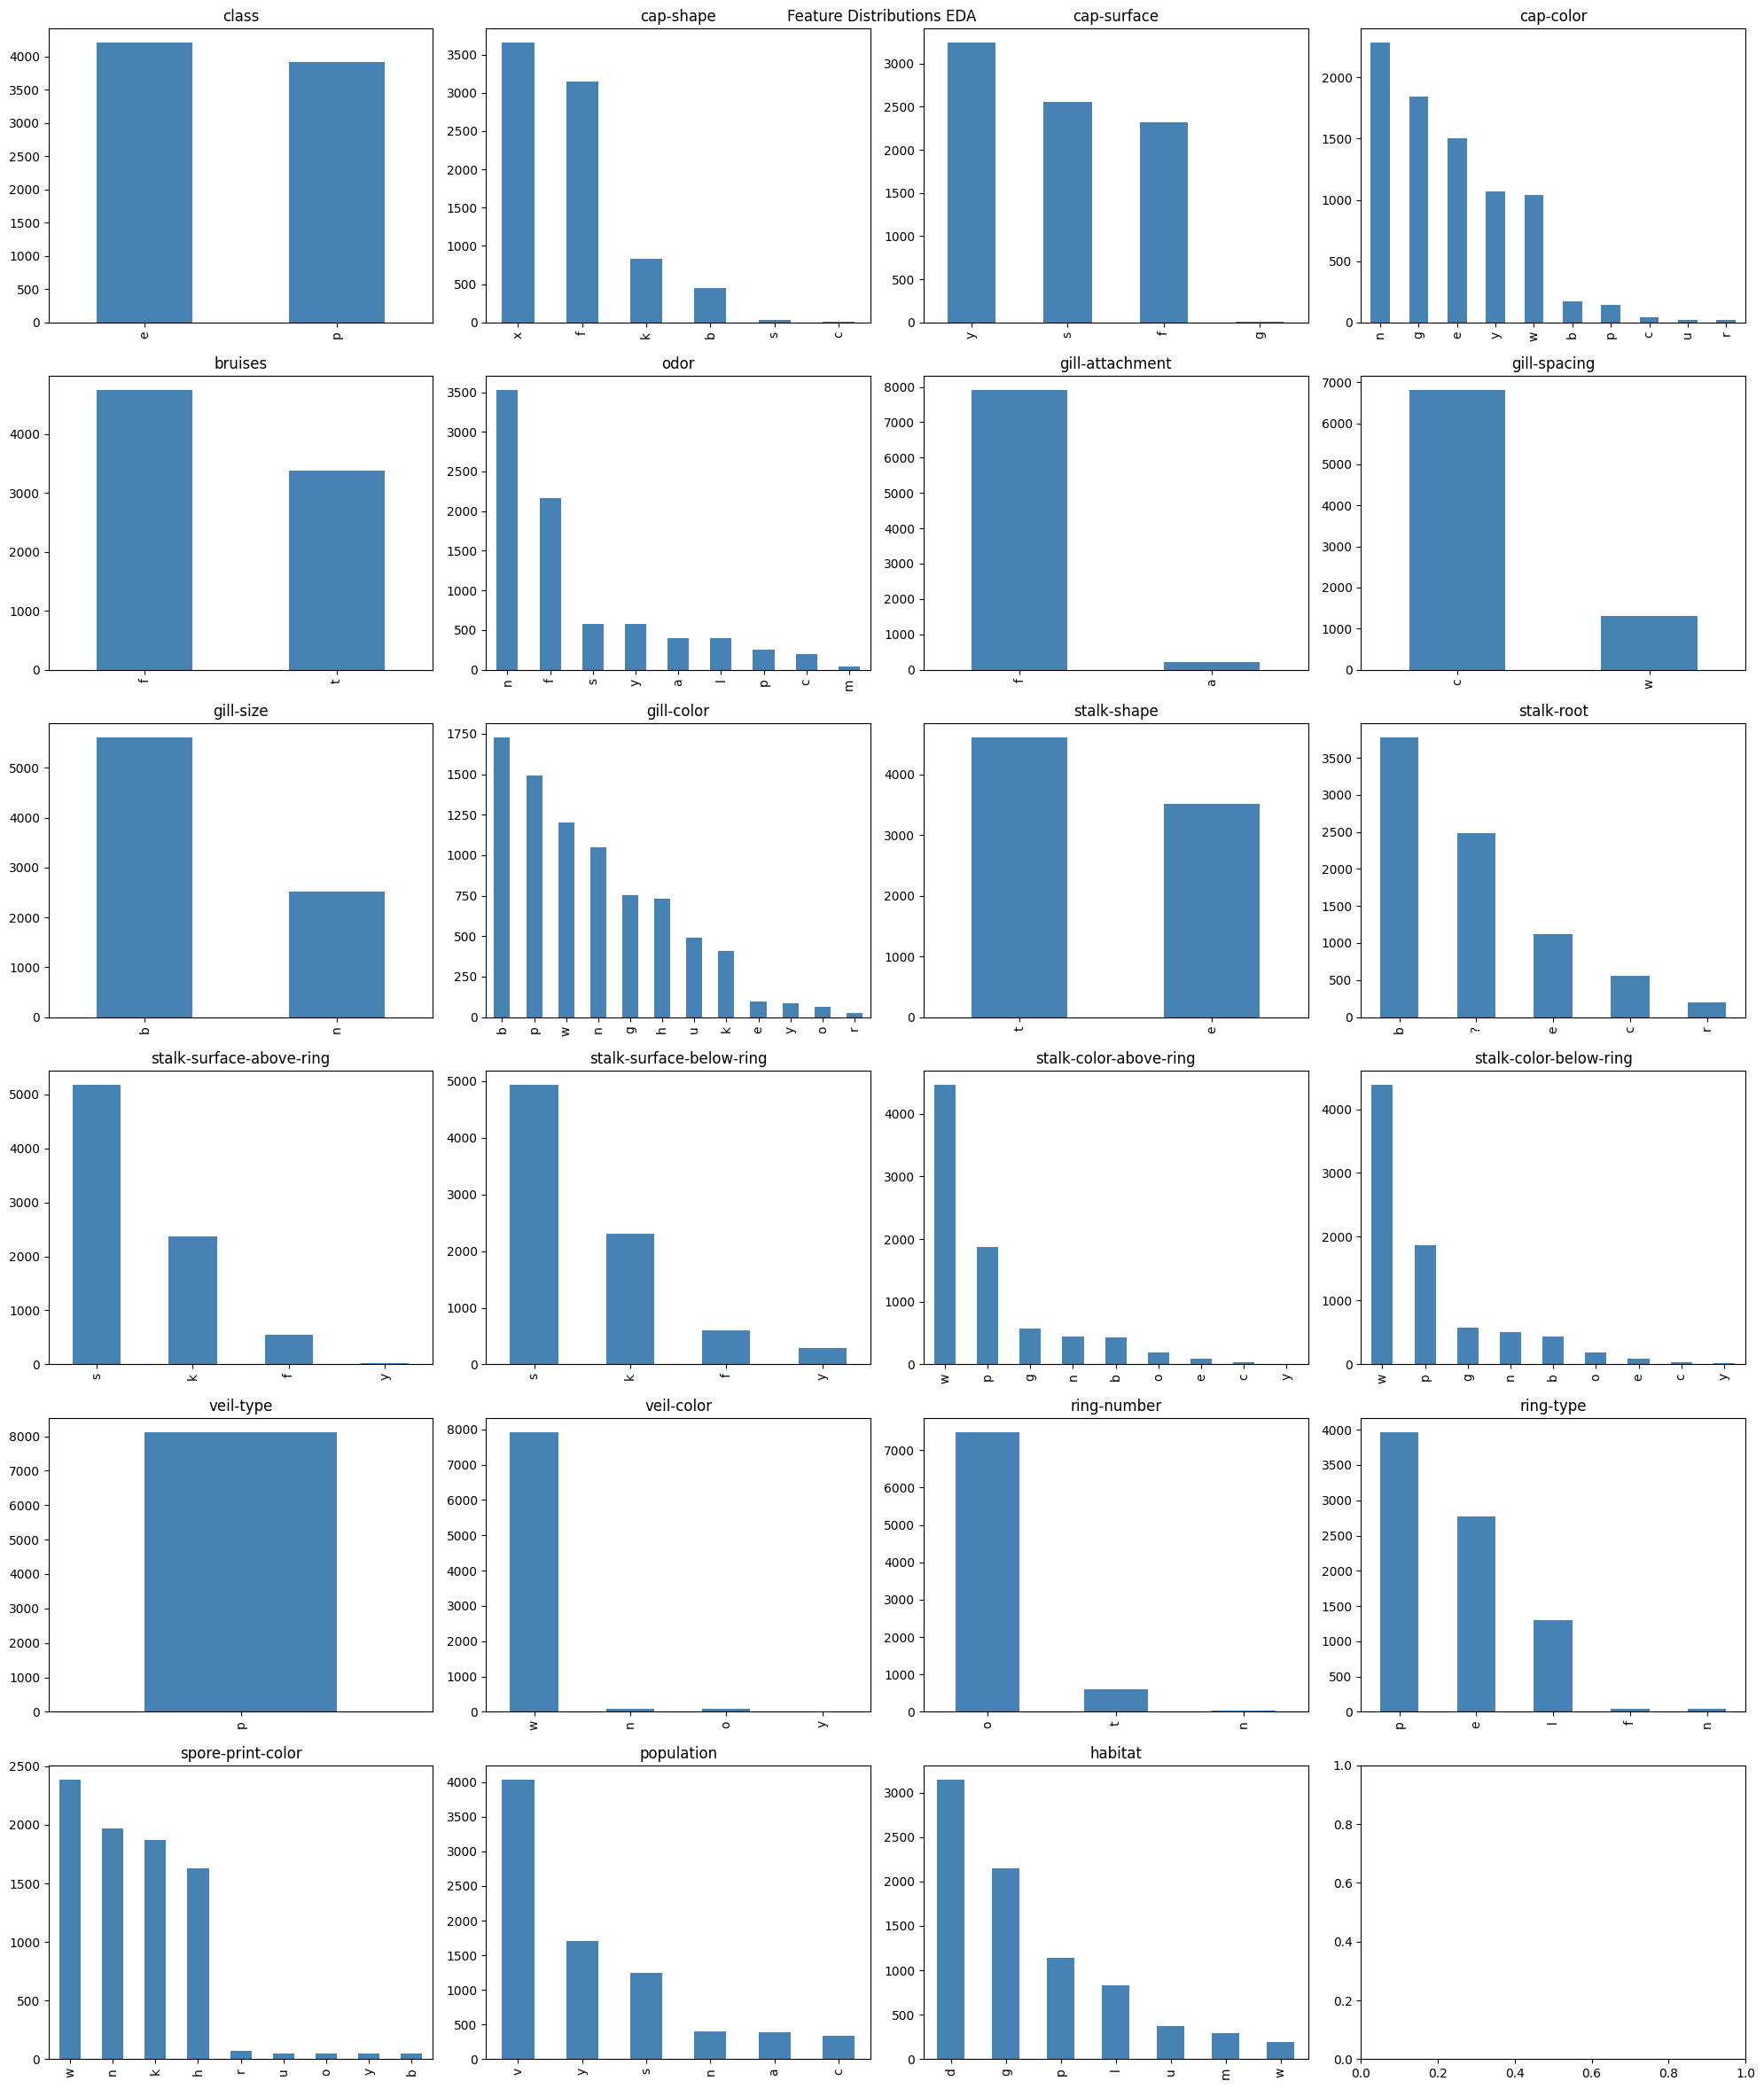

In [71]:
# check class balance
n_cols = 4
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')


plt.suptitle('Feature Distributions EDA')
plt.tight_layout()
plt.show()

In [72]:
# lof

lof = LocalOutlierFactor(n_neighbors=20)
labels = lof.fit_predict(df_encoded)

n_outliers = (labels == -1).sum()

print(f'Outliers: {n_outliers}, percent: {n_outliers/len(df)*100:.2f}%')
# there are only 6 outliers lol

df_no_outliers = df_encoded[labels == 1].reset_index(drop=True)

print(f'With outliers: {len(df_encoded)}')
print(f'No outliers: {len(df_no_outliers)}')


Outliers: 6, percent: 0.07%
With outliers: 8124
No outliers: 8118


## D Decision Tree

In [73]:

dt = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
    criterion='gini'
)

# E Feature Engineering

In [74]:

# decode
df_fe = df_no_outliers.copy()
for col in df_fe.columns:
    df_fe[col] = encoders[col].inverse_transform(df_fe[col].astype(int))

# population and habitat
df_fe['pop_habitat'] = df_fe['population'] + '_' + df_fe['habitat']

odor_map = {
    'a' :'o',
    'l' : 'o',
    'c' : 'o',
    'y' : 'o',
    'f' : 'o',
    'm' : 'o',
    'p' : 'o',
    's' : 'o',
    'n' : 'n'
}

df_fe["odorous"] = df_fe["odor"].map(odor_map)

## F Empirical Study

In [75]:
df_fe_outliers = df_encoded.copy()
for col in df_fe_outliers.columns:
    df_fe_outliers[col] = encoders[col].inverse_transform(df_fe_outliers[col].astype(int))

df_fe_outliers['pop_habitat'] = df_fe_outliers['population'] + '_' + df_fe_outliers['habitat']
df_fe_outliers['odorous'] = df_fe_outliers['odor'].map(odor_map)

for df_temp in [df_fe, df_fe_outliers]:
    for col in df_temp.columns:
        le = LabelEncoder()
        df_temp[col] = le.fit_transform(df_temp[col].astype(str))

In [76]:

configs = {
    'baseline': df_encoded,
    'no out, no fe': df_no_outliers,
    'out, fe' : df_fe_outliers,
    'no out, fe': df_fe
}

results = {}


for name, df_config in configs.items():
    X = df_config.drop(columns = ['class'])
    y = df_config['class']

    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

    dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
    print('with in built cross_val_score function')

    scores = cross_val_score(dt, X_train_val, y_train_val, cv=4, scoring = 'f1')

    results[name] = (scores, X_train_val, X_test, y_train_val, y_test)

    print(f'Name: {name} | F1 Mean {scores.mean() * 100:.2f}')

    print('with curstom kfold function')

    kfold(dt, X_train_val, y_train_val)

    print()
    print()




    

with in built cross_val_score function
Name: baseline | F1 Mean 97.63
with curstom kfold function
Mean F1: 97.79


with in built cross_val_score function
Name: no out, no fe | F1 Mean 97.69
with curstom kfold function
Mean F1: 97.81


with in built cross_val_score function
Name: out, fe | F1 Mean 99.68
with curstom kfold function
Mean F1: 99.71


with in built cross_val_score function
Name: no out, fe | F1 Mean 99.79
with curstom kfold function
Mean F1: 99.97




In [77]:
param_configs = {
    'gini, no lim' : DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42),
    'gini, md=5': DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42),
    'gini, md=10': DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42),
    'gini, md=20, min=5': DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_split=5, random_state=42),
    'gini, md=50': DecisionTreeClassifier(criterion='gini', max_depth=50, random_state=42),
    'entropy, no lim': DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42),
    'entropy, md=10': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42),

}

X = df_fe.drop(columns = ['class'])
y = df_fe['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

for name, dt_configs in param_configs.items():
    print('with in built cross_val_score function')
    scores = cross_val_score(dt_configs, X_train_val, y_train_val, cv=4, scoring='f1')
    print(f'Name: {name} | F1 Mean {scores.mean() * 100:.2f}')
    print('with curstom kfold function')
    kfold(dt, X_train_val, y_train_val)

    print()
    print()

with in built cross_val_score function
Name: gini, no lim | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=5 | F1 Mean 99.79
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=10 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=20, min=5 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=50 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: entropy, no lim | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: entropy, md=10 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97




In [78]:

X = df_fe.drop(columns = ['class'])
y = df_fe['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

best_dt = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
    criterion='gini'
)
best_dt.fit(X_train_val, y_train_val)

# eval
y_pred = best_dt.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       631
   poisonous       1.00      1.00      1.00       587

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218



## G Result Analysis

The feature engineering did lead to improved results. The baseline model performed the worst with a mean f1 score of 97.63%. With outliers removed it achieved 97.69%; with feature engineering 99.68% and with ourliers removed and feature engineering 99.79%. This shows that feature engineering has a positive impact on the the data set, though it is minimal as the model already performs well. Outlier removal also had an impact but it was very small which is most likely due to the fact that only 6 outliers were detected and removed. During parameter tuning, nearly all models achieved a mean f1 of 1.0% except for the gini model with a depth of 5. For this reason the final best model chosen was the gini model with max_depth set to None. The model generalizes well, in the final test data an f1 score of 1.0% was achieved. The exceptional performance of the model is most likely due to the dataset being very good for classification tasks.

It should be noted that the above is when using the in built cross_val_score function which takes a combined set of the training and validation data and performs the split internally. When using a custom function that splits the train_val set into seperate data sets and performs kfold manually the model ranking remains the same however the greatest mean f1 achieved is 99.97% instead of 99.79%. Additionally, the effect of parameter tuning is the same however Mean f1 drops from 1.0% to 99.97%.